In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Load the data
df = pd.read_csv('bank_transactions_data_2.csv')

# Display basic info
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (2512, 16)

First 5 rows:
  TransactionID AccountID  TransactionAmount      TransactionDate  \
0      TX000001   AC00128              14.09  2023-04-11 16:29:14   
1      TX000002   AC00455             376.24  2023-06-27 16:44:19   
2      TX000003   AC00019             126.29  2023-07-10 18:16:08   
3      TX000004   AC00070             184.50  2023-05-05 16:32:11   
4      TX000005   AC00411              13.45  2023-10-16 17:51:24   

  TransactionType   Location DeviceID      IP Address MerchantID Channel  \
0           Debit  San Diego  D000380  162.198.218.92       M015     ATM   
1           Debit    Houston  D000051     13.149.61.4       M052     ATM   
2           Debit       Mesa  D000235  215.97.143.157       M009  Online   
3           Debit    Raleigh  D000187  200.13.225.150       M002  Online   
4          Credit    Atlanta  D000308    65.164.3.100       M091  Online   

   CustomerAge CustomerOccupation  TransactionDuration  LoginAttempts  \
0           70

In [3]:
numerical_cols = ['TransactionAmount', 'CustomerAge', 'TransactionDuration', 'LoginAttempts', 'AccountBalance']
df[numerical_cols].describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


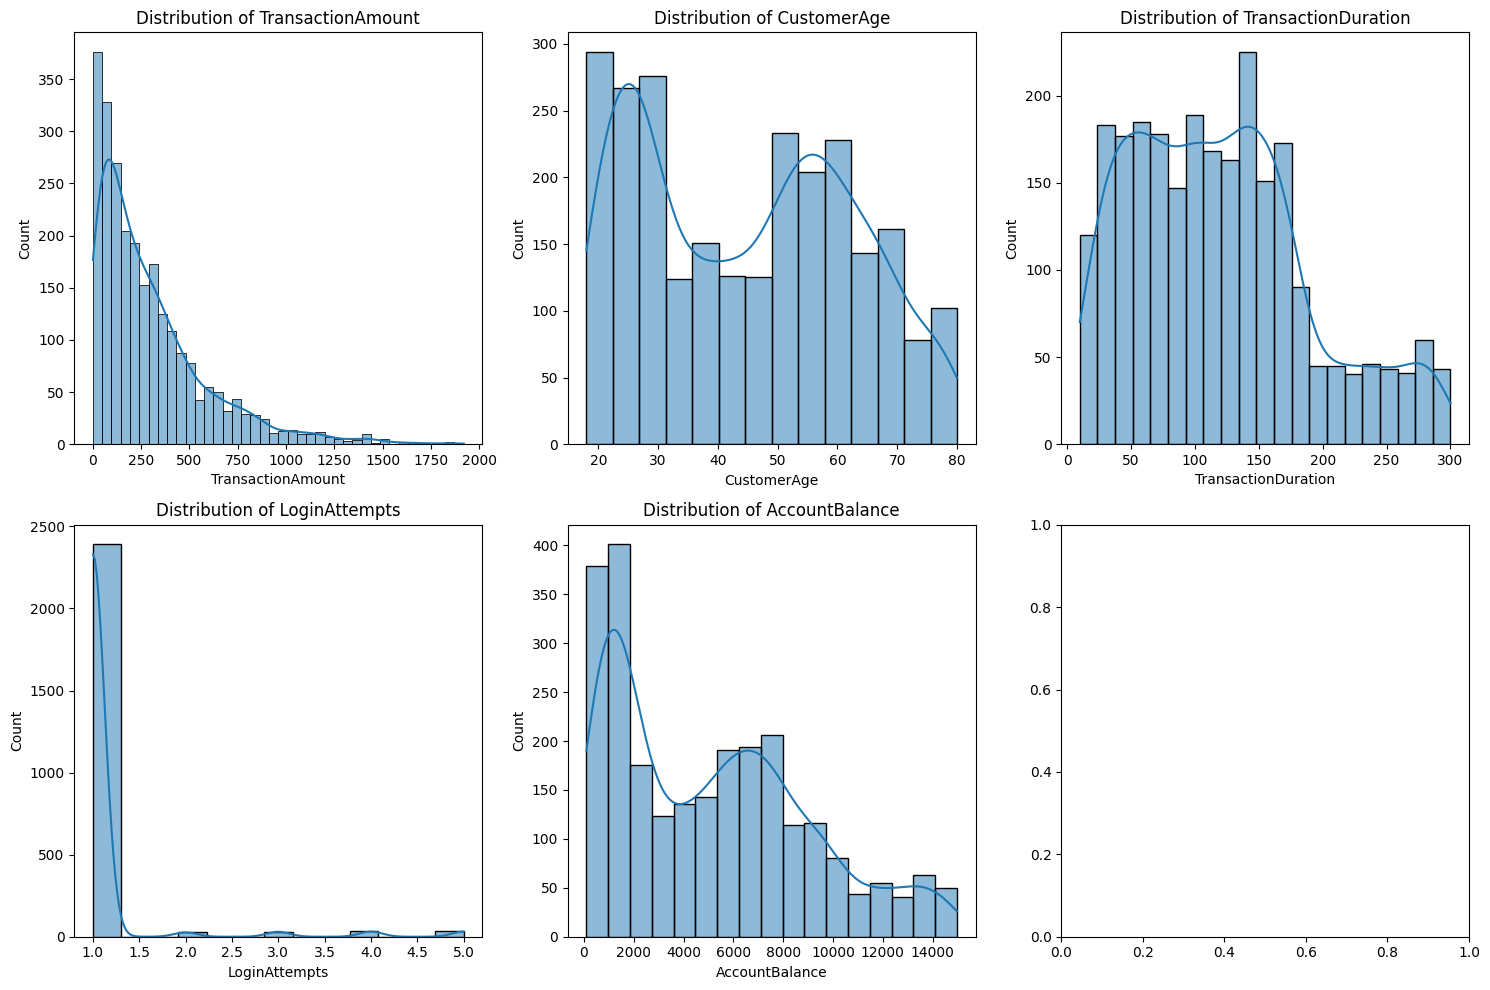

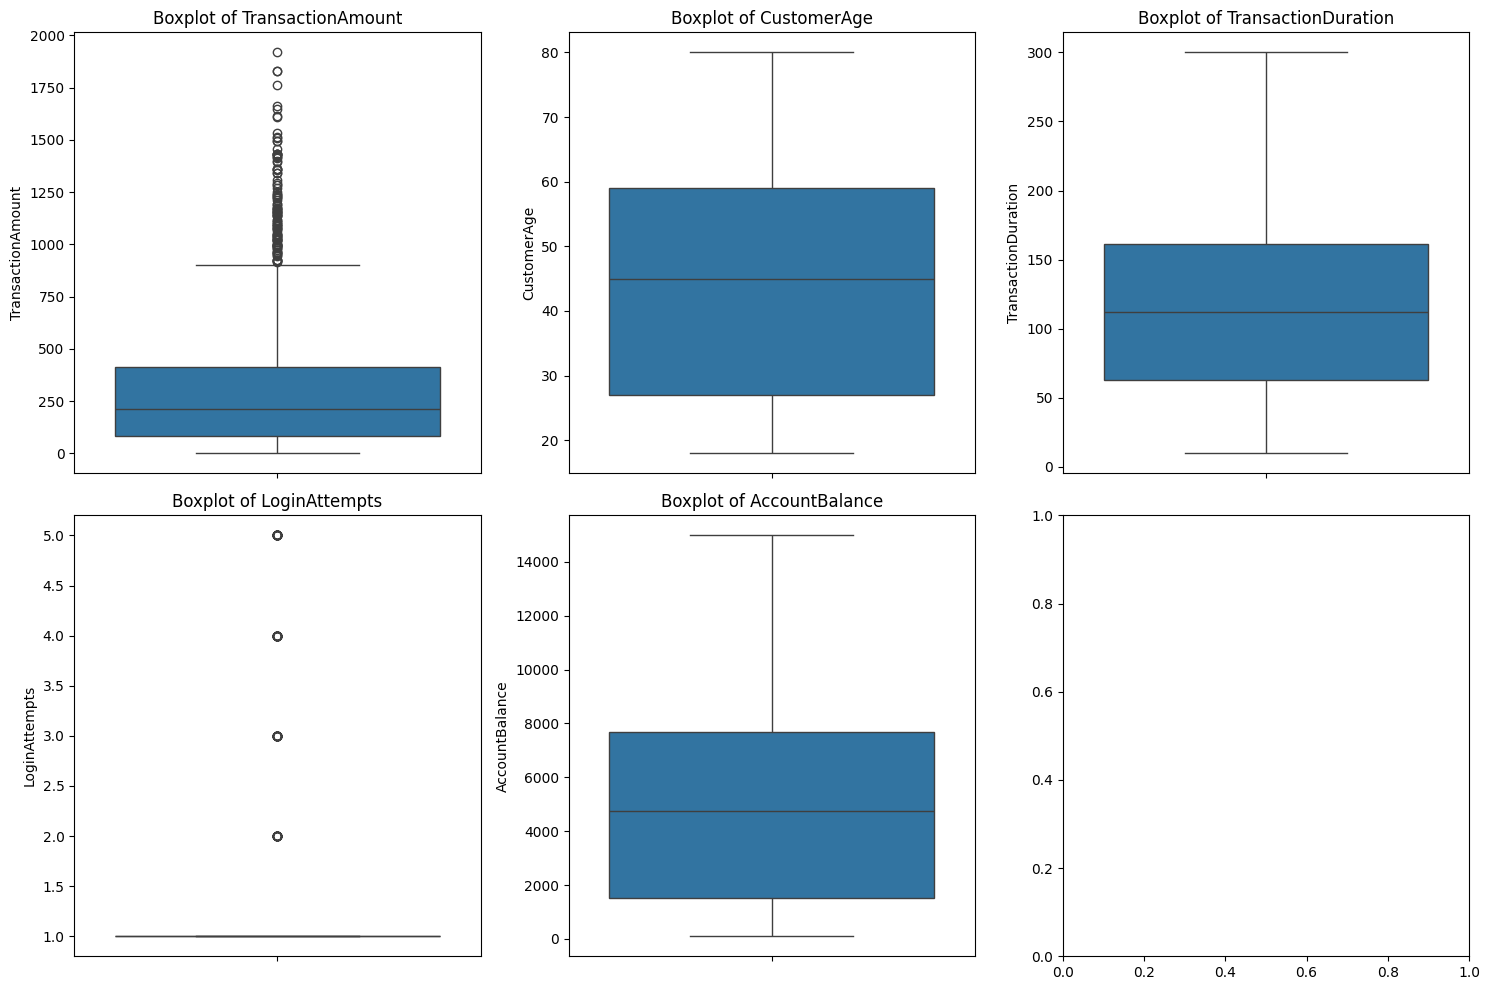

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Boxplots to identify outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [5]:
categorical_cols = ['TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
                    'Channel', 'CustomerOccupation']

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))  # show top 10 categories
    print(f"Unique values: {df[col].nunique()}")


--- TransactionType ---
TransactionType
Debit     1944
Credit     568
Name: count, dtype: int64
Unique values: 2

--- Location ---
Location
Fort Worth       70
Los Angeles      69
Oklahoma City    68
Charlotte        68
Philadelphia     67
Tucson           67
Omaha            65
Miami            64
Memphis          63
Detroit          63
Name: count, dtype: int64
Unique values: 43

--- DeviceID ---
DeviceID
D000548    9
D000142    9
D000451    9
D000697    9
D000203    9
D000663    9
D000315    9
D000602    8
D000670    8
D000649    8
Name: count, dtype: int64
Unique values: 681

--- IP Address ---
IP Address
200.136.146.93    13
49.31.186.82      11
173.135.78.201    10
9.230.41.239      10
166.79.195.157    10
147.119.62.178    10
139.23.212.102     9
49.29.37.185       9
133.63.96.21       9
214.67.148.245     9
Name: count, dtype: int64
Unique values: 592

--- MerchantID ---
MerchantID
M026    45
M066    34
M028    33
M014    33
M065    33
M013    33
M070    32
M068    32
M001    

In [6]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['YearMonth'] = df['TransactionDate'].dt.to_period('M')
df['Hour'] = df['TransactionDate'].dt.hour
df['Weekday'] = df['TransactionDate'].dt.day_name()

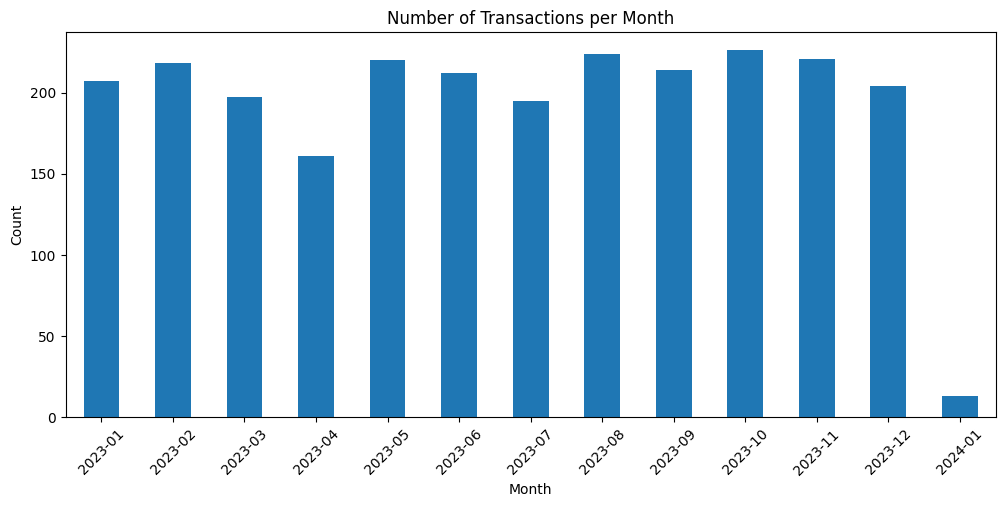

In [7]:
# Monthly transaction count
monthly_counts = df['YearMonth'].value_counts().sort_index()
plt.figure(figsize=(12,5))
monthly_counts.plot(kind='bar')
plt.title('Number of Transactions per Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

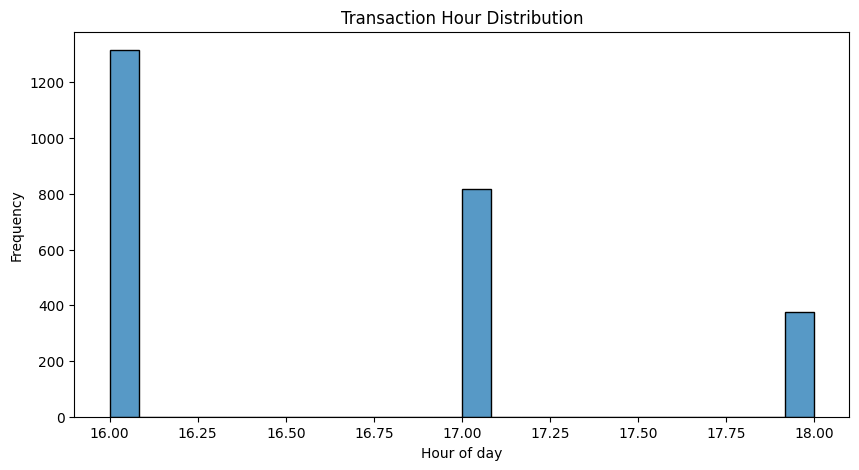

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df['Hour'], bins=24, kde=False)
plt.title('Transaction Hour Distribution')
plt.xlabel('Hour of day')
plt.ylabel('Frequency')
plt.show()

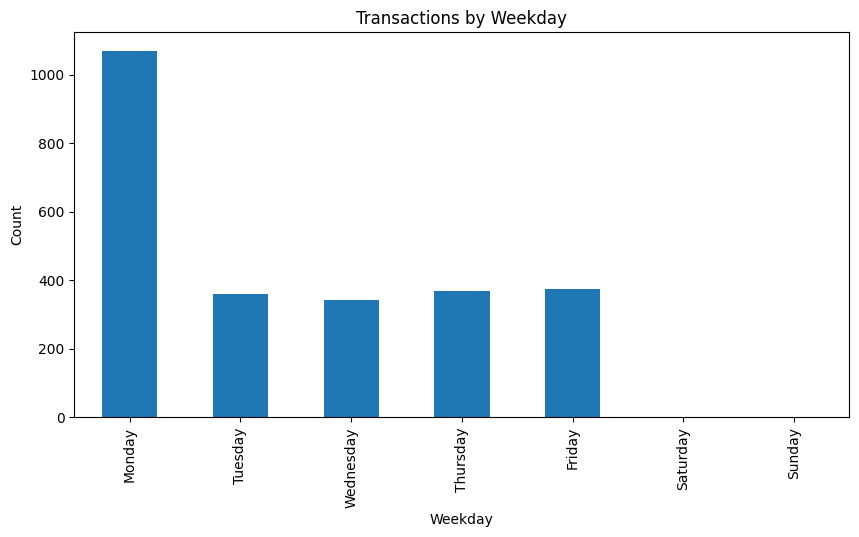

In [9]:
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['Weekday'] = pd.Categorical(df['Weekday'], categories=weekday_order, ordered=True)
weekday_counts = df['Weekday'].value_counts().sort_index()
plt.figure(figsize=(10,5))
weekday_counts.plot(kind='bar')
plt.title('Transactions by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Count')
plt.show()

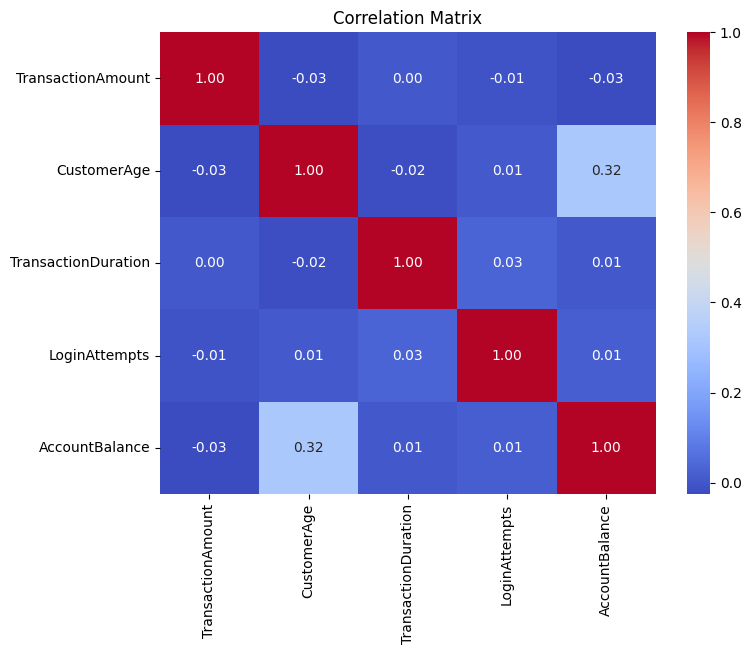

In [10]:
corr = df[numerical_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

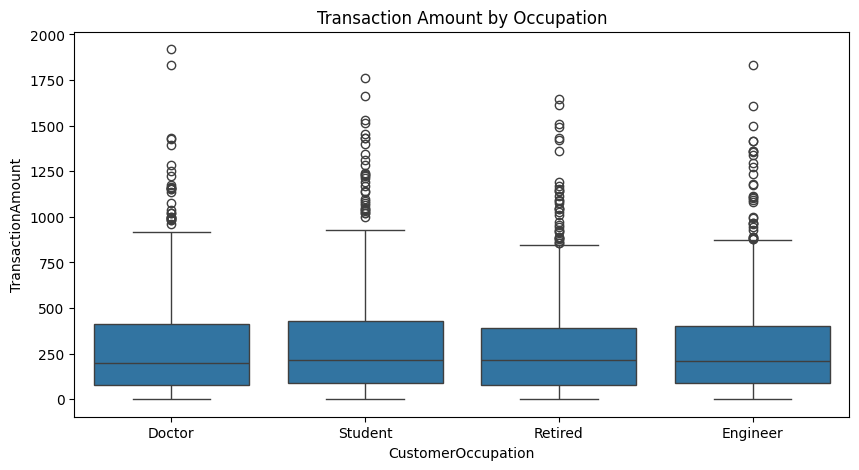

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='CustomerOccupation', y='TransactionAmount')
plt.title('Transaction Amount by Occupation')
plt.show()

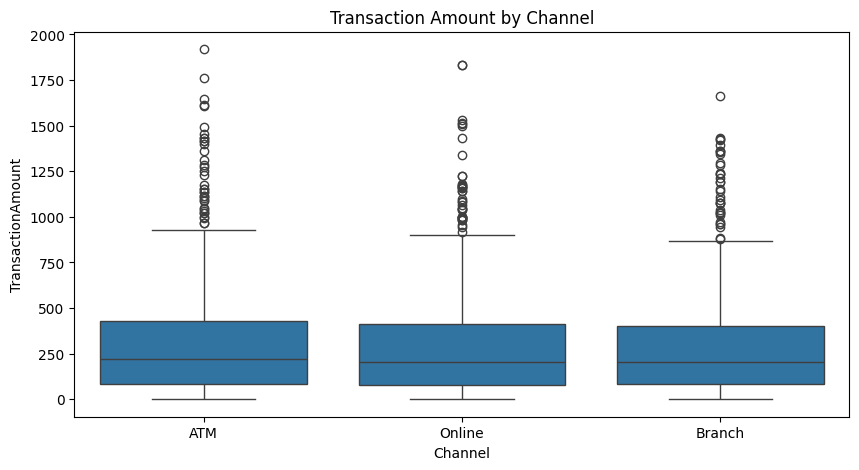

In [12]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Channel', y='TransactionAmount')
plt.title('Transaction Amount by Channel')
plt.show()

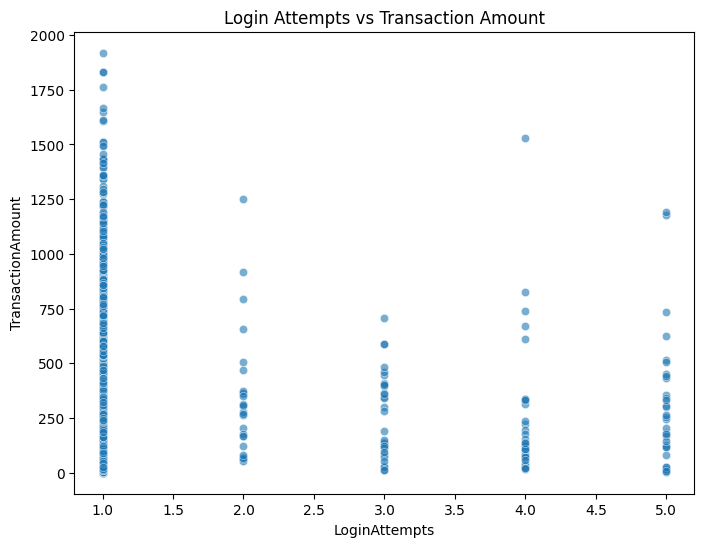

In [13]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='LoginAttempts', y='TransactionAmount', alpha=0.6)
plt.title('Login Attempts vs Transaction Amount')
plt.show()

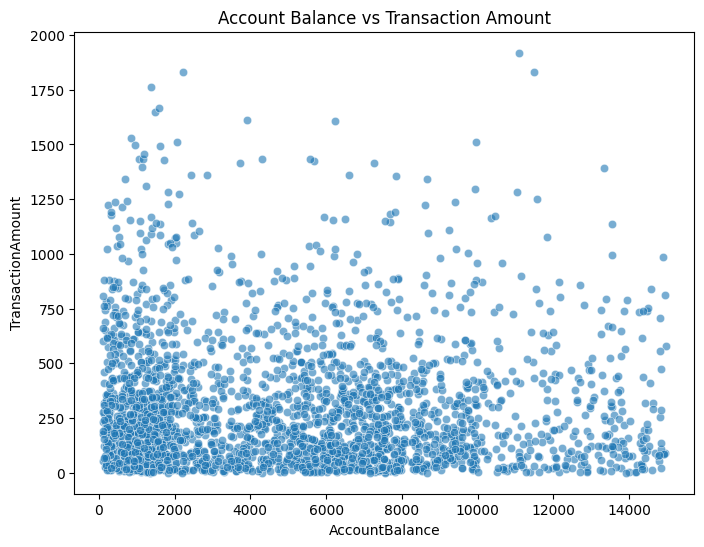

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='AccountBalance', y='TransactionAmount', alpha=0.6)
plt.title('Account Balance vs Transaction Amount')
plt.show()

In [15]:
high_amount = df[df['TransactionAmount'] > 1500]
print(f"High amount transactions (>1500): {len(high_amount)}")
print(high_amount[['TransactionID','TransactionAmount','AccountBalance','LoginAttempts']].head())

high_login = df[df['LoginAttempts'] >= 4]
print(f"\nTransactions with >=4 login attempts: {len(high_login)}")
print(high_login[['TransactionID','TransactionAmount','AccountBalance','LoginAttempts']].head())

High amount transactions (>1500): 11
     TransactionID  TransactionAmount  AccountBalance  LoginAttempts
340       TX000341            1830.00         2235.70              1
653       TX000654            1919.11        11090.24              1
755       TX000756            1607.55         6227.99              1
898       TX000899            1531.31          859.86              4
1247      TX001248            1647.74         1483.84              1

Transactions with >=4 login attempts: 64
    TransactionID  TransactionAmount  AccountBalance  LoginAttempts
26       TX000027             246.93          673.35              5
91       TX000092             223.85         2929.91              4
147      TX000148             514.95          421.93              5
266      TX000267              66.90         5238.71              4
274      TX000275            1176.28          323.69              5


In [16]:
merchant_avg = df.groupby('MerchantID')['TransactionAmount'].mean().sort_values(ascending=False).head(10)
print("Top 10 merchants by avg transaction amount:")
print(merchant_avg)

Top 10 merchants by avg transaction amount:
MerchantID
M075    465.585789
M081    441.511739
M048    421.338077
M012    409.340952
M086    393.594762
M032    388.025000
M006    383.873125
M018    374.734444
M093    369.583043
M082    365.976111
Name: TransactionAmount, dtype: float64


In [17]:
location_vol = df['Location'].value_counts().head(10)
print("\nTop 10 locations by transaction count:")
print(location_vol)


Top 10 locations by transaction count:
Location
Fort Worth       70
Los Angeles      69
Oklahoma City    68
Charlotte        68
Philadelphia     67
Tucson           67
Omaha            65
Miami            64
Memphis          63
Detroit          63
Name: count, dtype: int64


In [18]:
ip_counts = df['IP Address'].value_counts().head(10)
print("\nTop 10 IP addresses by transaction count:")
print(ip_counts)


Top 10 IP addresses by transaction count:
IP Address
200.136.146.93    13
49.31.186.82      11
173.135.78.201    10
9.230.41.239      10
166.79.195.157    10
147.119.62.178    10
139.23.212.102     9
49.29.37.185       9
133.63.96.21       9
214.67.148.245     9
Name: count, dtype: int64
